In [27]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv('job_salary_prediction_dataset.csv')

In [11]:
print("Dataset Shape:")
print(df.shape)
print("\nDataset Info:")
print(df.info())




Dataset Shape:
(250000, 10)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB
None


In [12]:
print("\nMissing Values per Column:")
print(df.isnull().sum())
print("\nDuplicated Rows:")
print(df.duplicated().sum())
print("\nNumrical Features Summary Stats:")
print(df.describe())


Missing Values per Column:
job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

Duplicated Rows:
0

Numrical Features Summary Stats:
       experience_years   skills_count  certifications         salary
count     250000.000000  250000.000000   250000.000000  250000.000000
mean          10.005408       9.997812        2.491928  145718.080524
std            6.060602       5.479288        1.706475   37407.952729
min            0.000000       1.000000        0.000000   31867.000000
25%            5.000000       5.000000        1.000000  119358.000000
50%           10.000000      10.000000        2.000000  143453.000000
75%           15.000000      15.000000        4.000000  169492.000000
max           20.000000      19.000000        5.000000  333046.000000


## Salary Distribution

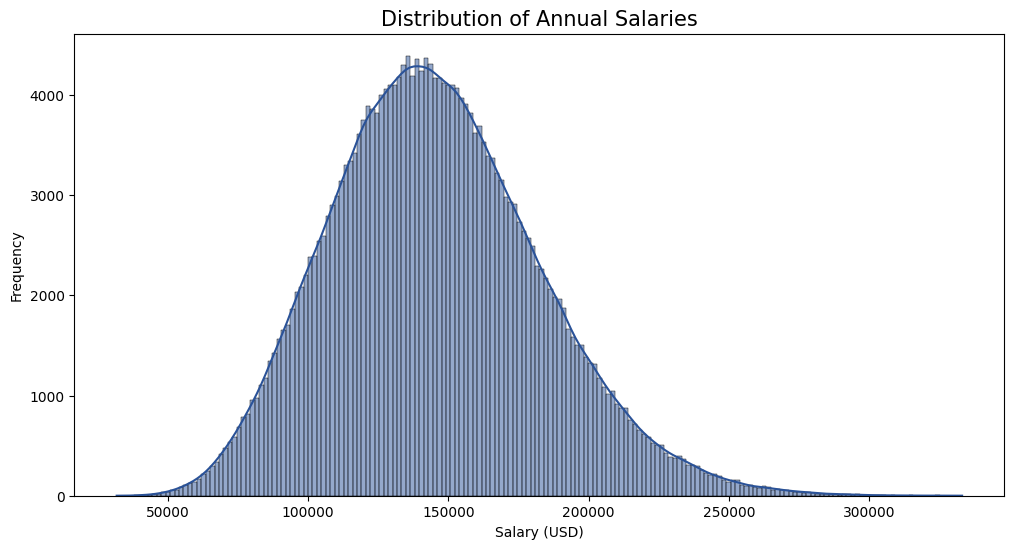

In [15]:
plt.figure(figsize=(12, 6))
sns.histplot(df['salary'], kde=True, color='#2a5298')
plt.title('Distribution of Annual Salaries', fontsize=15)
plt.xlabel('Salary (USD)')
plt.ylabel('Frequency')
plt.show()

## The Experience-Salary Correlation

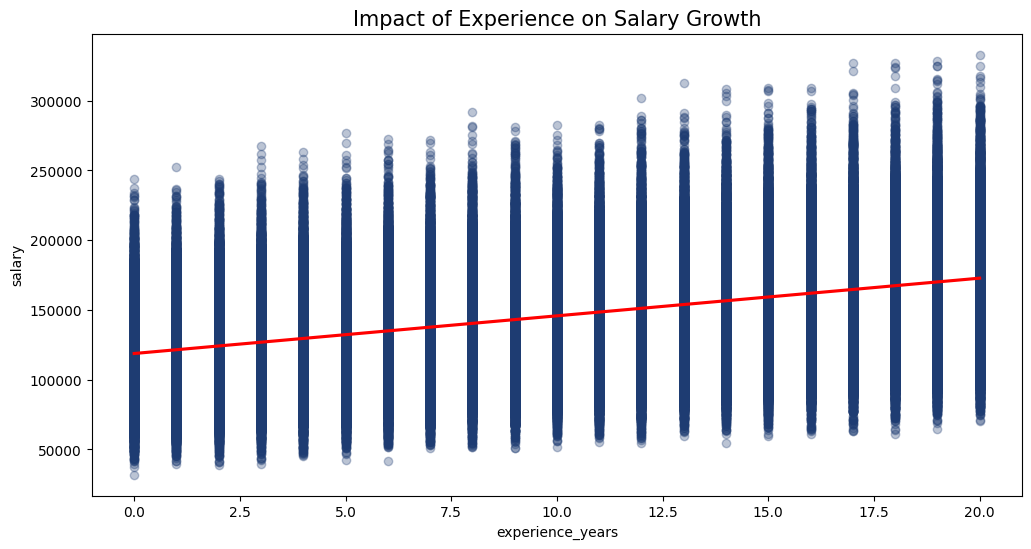

In [16]:
plt.figure(figsize=(12, 6))
sns.regplot(data=df, x='experience_years', y='salary', 
            scatter_kws={'alpha':0.3, 'color':'#1e3c72'}, line_kws={'color':'red'})
plt.title('Impact of Experience on Salary Growth', fontsize=15)
plt.show()

## Role & Education

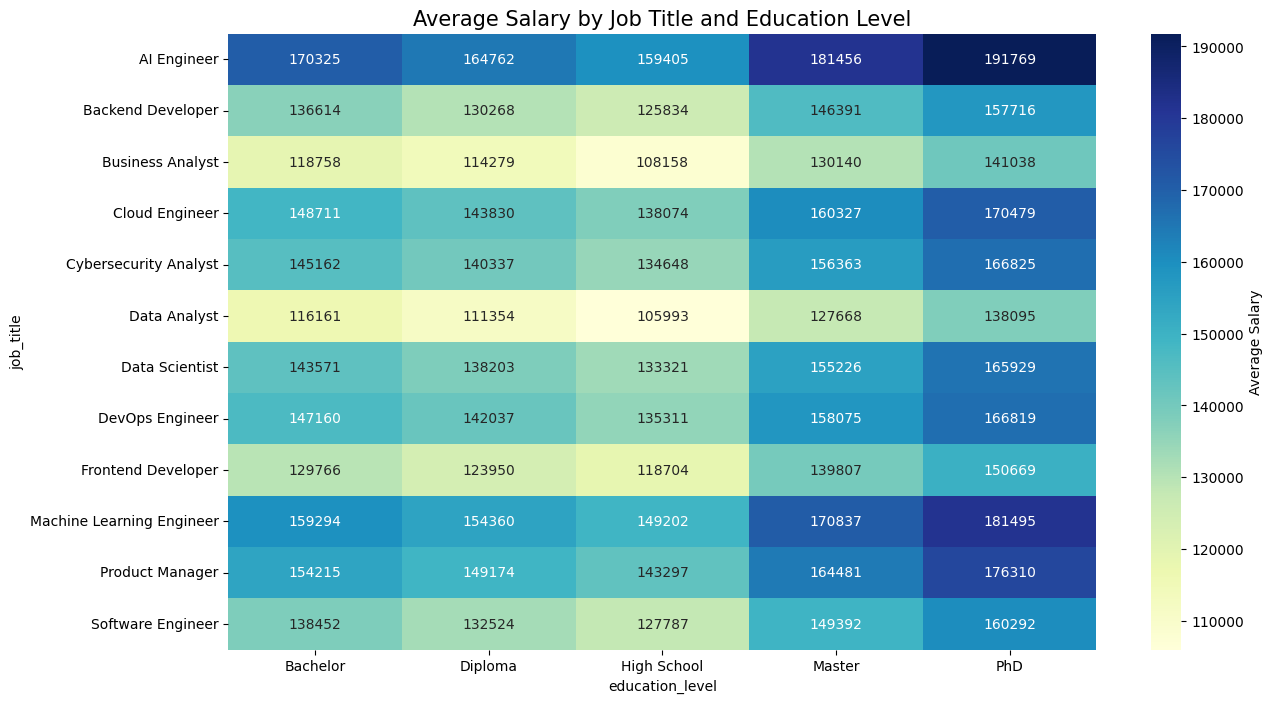

In [17]:
pivot_table = df.pivot_table(index='job_title', columns='education_level', values='salary', aggfunc='mean')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Average Salary'})
plt.title('Average Salary by Job Title and Education Level', fontsize=15)
plt.show()

##  Location vs. Remote Work

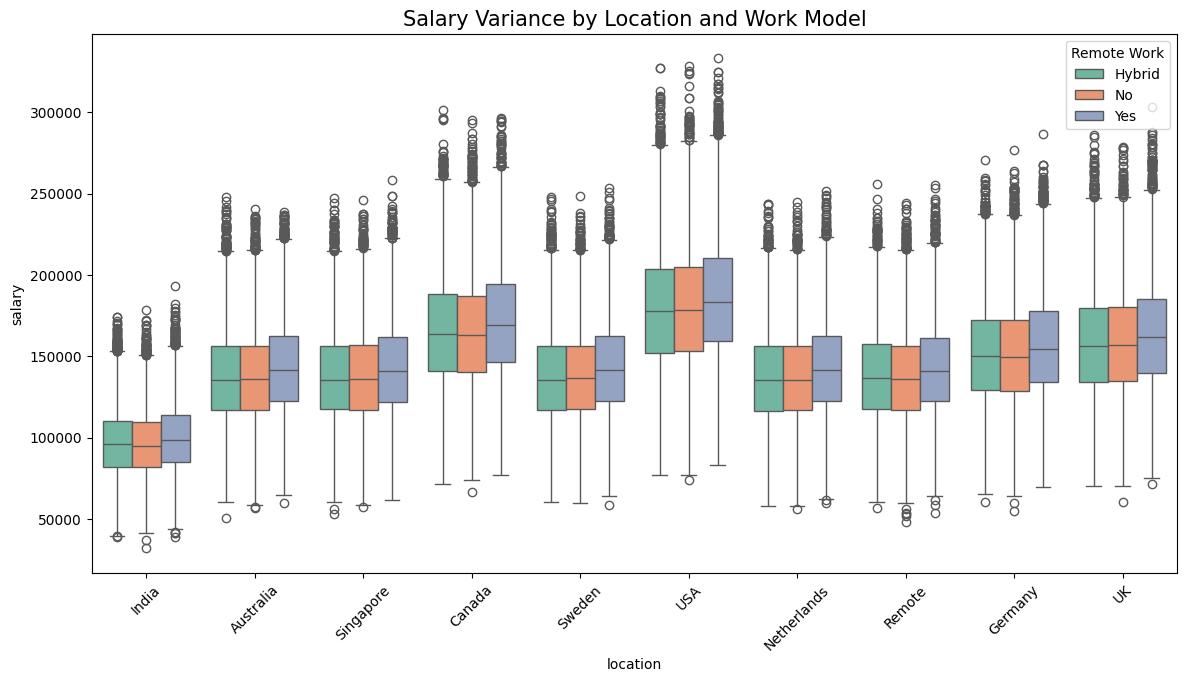

In [18]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x='location', y='salary', hue='remote_work', palette='Set2')
plt.xticks(rotation=45)
plt.title('Salary Variance by Location and Work Model', fontsize=15)
plt.legend(title='Remote Work', loc='upper right')
plt.show()

Text(0.5, 1.0, 'Correlation Heatmap of Numerical Features')

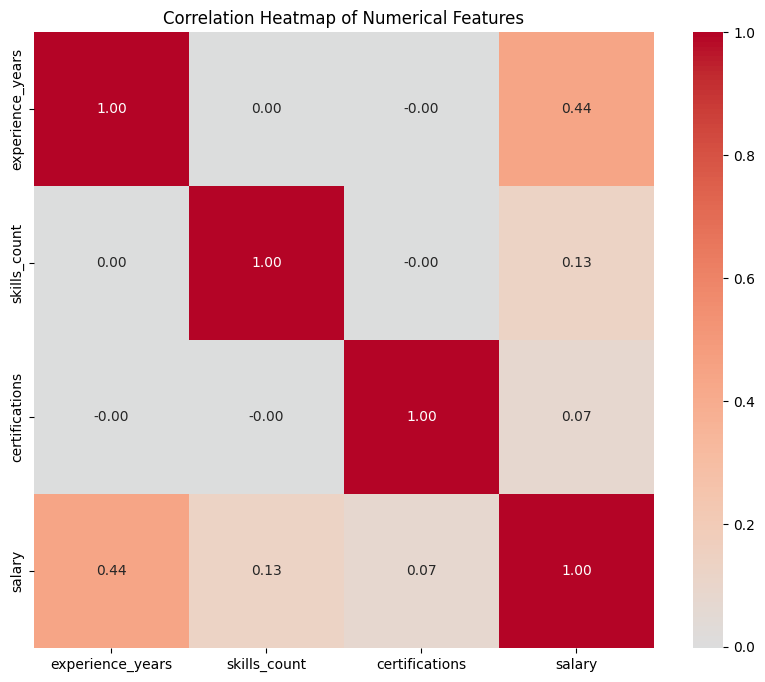

In [19]:

plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title("Correlation Heatmap of Numerical Features")

## Feature Engineering

In [21]:
df["log_salary"] = np.log1p(df["salary"])

bins = [0, 2, 5, 10, 15, 20]
labels = ["entry", "junior", "mid", "senior", "expert"]
df["experience_level"] = pd.cut(df["experience_years"], bins=bins, labels=labels)

df["skills_level"] = pd.cut(df["skills_count"], bins=[0,5,10,15,20], labels=["low","mid","high","expert"])

df["skills_per_year"] = df["skills_count"] / (df["experience_years"] + 1)

df["certs_per_year"] = df["certifications"] / (df["experience_years"] + 1)

edu_map = {
    "High School": 0,
    "Diploma": 1,
    "Bachelor": 2,
    "Master": 3,
    "PhD": 4
}
df["education_level_encoded"] = df["education_level"].map(edu_map)

size_map = {
    "Startup": 0,
    "Small": 1,
    "Medium": 2,
    "Large": 3,
    "Enterprise": 4
}
df["company_size_encoded"] = df["company_size"].map(size_map)

df["is_remote"] = (df["remote_work"] == "Yes").astype(int)

df = df.drop(columns=["education_level", "company_size", "is_remote"])

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   job_title                250000 non-null  object  
 1   experience_years         250000 non-null  int64   
 2   skills_count             250000 non-null  int64   
 3   industry                 250000 non-null  object  
 4   location                 250000 non-null  object  
 5   remote_work              250000 non-null  object  
 6   certifications           250000 non-null  int64   
 7   salary                   250000 non-null  int64   
 8   log_salary               250000 non-null  float64 
 9   experience_level         238196 non-null  category
 10  skills_level             250000 non-null  category
 11  skills_per_year          250000 non-null  float64 
 12  certs_per_year           250000 non-null  float64 
 13  education_level_encoded  250000 non-null  in

In [23]:
for col in df.select_dtypes(include=["object", "category"]):
    print(df[col].value_counts())

job_title
Backend Developer            21125
Cybersecurity Analyst        20959
Product Manager              20950
AI Engineer                  20945
Data Scientist               20890
DevOps Engineer              20889
Software Engineer            20876
Data Analyst                 20722
Cloud Engineer               20686
Machine Learning Engineer    20677
Business Analyst             20648
Frontend Developer           20633
Name: count, dtype: int64
industry
Finance          25393
Consulting       25258
Media            25034
Manufacturing    25024
Technology       24903
Government       24901
Healthcare       24898
Education        24889
Telecom          24859
Retail           24841
Name: count, dtype: int64
location
Australia      25258
Canada         25165
Sweden         25100
Remote         25065
Singapore      25035
USA            24931
UK             24927
India          24895
Netherlands    24861
Germany        24763
Name: count, dtype: int64
remote_work
No        83621
Hybrid

In [26]:
X = df.drop(columns="log_salary")
y = df["log_salary"]

num_features = [
    "experience_years",
    "skills_count",
    "certifications",
    "skills_per_year",
    "certs_per_year"
]

ordinal_categorical = [
    "experience_level",
    "skills_level"
]

ordinal_numeric = [
    "education_level_encoded",
    "company_size_encoded"
]

onehot_features = [
    "job_title",
    "industry",
    "location",
    "remote_work"
]

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("encoder", OrdinalEncoder(
        categories=[
            ["entry", "junior", "mid", "senior", "expert", "unknown"],
            ["low", "mid", "high", "expert"]
        ]
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
    ("num", StandardScaler(), num_features),
    ("ord_cat", ordinal_pipeline, ordinal_categorical),
    ("onehot", OneHotEncoder(handle_unknown="ignore"), onehot_features),
    ("passthrough", "passthrough", ordinal_numeric)
    ]
)

In [29]:
df_encoded = pd.get_dummies(df, columns=df.select_dtypes(exclude='number').columns.tolist(), drop_first=True, dtype=int)
df_encoded.head()

,experience_years,skills_count,certifications,salary,log_salary,skills_per_year,certs_per_year,education_level_encoded,company_size_encoded,job_title_Backend Developer,...,location_USA,remote_work_No,remote_work_Yes,experience_level_junior,experience_level_mid,experience_level_senior,experience_level_expert,skills_level_mid,skills_level_high,skills_level_expert
0,10,2,2,109413,11.602894,0.181818,0.181818,2,2,0,...,0,0,0,0,1,0,0,0,0,0
1,5,17,0,93764,11.448547,2.833333,0.000000,2,1,0,...,0,1,0,1,0,0,0,0,0,1
2,18,4,1,148123,11.905805,0.210526,0.052632,4,2,0,...,0,1,0,0,0,0,1,0,0,0
3,19,13,0,189123,12.150158,0.650000,0.000000,4,2,0,...,0,0,1,0,0,0,1,0,1,0
4,15,7,0,165069,12.014125,0.437500,0.000000,2,3,0,...,0,0,1,0,0,1,0,1,0,0


In [31]:
X = df_encoded.drop('salary', axis=1)
y = df_encoded['salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression'       : LinearRegression(),
    'Random Forest'           : RandomForestRegressor(random_state=42),
    'Gradient Boosting'       : GradientBoostingRegressor(random_state=42),
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        'Model'   : name,
        'MAE'     : round(mean_absolute_error(y_test, y_pred), 2),
        'RMSE'    : round(np.sqrt(mean_squared_error(y_test, y_pred)), 2),
        'R2 Score': round(r2_score(y_test, y_pred), 4)
    })

results_df = pd.DataFrame(results).sort_values('R2 Score', ascending=False)
print(results_df)

               Model      MAE     RMSE  R2 Score
1      Random Forest     1.03    13.20    1.0000
2  Gradient Boosting   278.37   369.12    0.9999
0  Linear Regression  4056.83  5940.85    0.9746
